In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

Some of the information in this workbook comes from Python Data Science Handbook by Jake VanderPlas, but with modifications

In [2]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60, resize=1)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 125, 94)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(faces.data, faces.target)

In [4]:
model = SVC(kernel='linear', C=2.0)
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

Wall time: 4.86 s
0.8160237388724035
Wall time: 1.63 s


In [5]:
model = GaussianNB()
%time model.fit(X_train,y_train)
%time print(model.score(X_test,y_test))

Wall time: 165 ms
0.4065281899109792
Wall time: 400 ms


In [6]:
model = KNeighborsClassifier(n_neighbors=5)
%time model.fit(X_train, y_train.ravel())
%time print(model.score(X_test, y_test))

Wall time: 19.7 ms
0.5459940652818991
Wall time: 525 ms


In [7]:
faces = fetch_lfw_people(min_faces_per_person=60, resize=0.5)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(faces.data, faces.target)

In [9]:
model = SVC(kernel='linear', C=2.0)
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

Wall time: 1.04 s
0.8219584569732937
Wall time: 388 ms


In [10]:
model = GaussianNB()
%time model.fit(X_train,y_train)
%time print(model.score(X_test,y_test))

Wall time: 40 ms
0.3768545994065282
Wall time: 100 ms


In [11]:
model = KNeighborsClassifier(n_neighbors=5)
%time model.fit(X_train, y_train.ravel())
%time print(model.score(X_test, y_test))

Wall time: 9.89 ms
0.5964391691394659
Wall time: 100 ms


In [12]:
model = SVC(kernel='rbf',gamma='scale')
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

Wall time: 1.84 s
0.7270029673590505
Wall time: 832 ms


In [13]:
gamma_range = np.logspace(-9, 3, 13)

In [14]:
gamma_range

array([1.e-09, 1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02,
       1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])

In [15]:
param_grid = [
  {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'kernel': ['linear']},
  {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'gamma': ['scale'], 'kernel': ['rbf']},
 ]
model = GridSearchCV(SVC(), param_grid, verbose=4)


In [16]:
param_grid

[{'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'kernel': ['linear']},
 {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
  'gamma': ['scale'],
  'kernel': ['rbf']}]

In [ ]:
model.fit(X_train,y_train)

RBF kernel has very poor performance if we don't set gamma to scale. 

In [ ]:
model.best_score_

In [ ]:
model.best_estimator_

If you look at the scores, there was very little difference between all the different Cs and linear

Looking at the Breast Cancer Dataset

In [ ]:
model.score(X_test,y_test)

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
cancer = load_breast_cancer()

In [18]:
X = cancer.data

PCA usually likes things to be normalised

https://www.researchgate.net/post/Is-it-necessary-to-normalize-data-before-performing-principle-component-analysis

The cancer data from before (kNN, remember I said to use standardscaler then) should certainly have some scaling beforehand

We should be selecting hyperparameters by cross-validation but I'm being lazy here as cross-validation is not the point of today's lecture

In [19]:
scale = StandardScaler()
pca = PCA(5)
X_pca = pca.fit_transform(scale.fit_transform(X))

In [20]:
X_pca.shape

(569, 5)

In [21]:
X.shape

(569, 30)

In [22]:
pca.explained_variance_ratio_

array([0.44272026, 0.18971182, 0.09393163, 0.06602135, 0.05495768])

In [23]:
pca.explained_variance_ratio_.sum()

0.847342743157355

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, cancer.target, random_state=42)

Without Any Reduction in features

(we need to do the Standard Scaler as part of the model)

In [25]:
from sklearn.model_selection import cross_val_score

In [26]:
model = make_pipeline(StandardScaler(), SVC(kernel='linear', C=2))
cross_val_score(model, X_train, y_train).mean()

0.969466484268126

In [27]:
model = make_pipeline(StandardScaler(), SVC(kernel='linear', C=2))
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

Wall time: 9.83 ms
0.972027972027972
Wall time: 0 ns


With Reduction to only 5 features

(we already used StandardScaler when making X_pca so no need again)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, cancer.target, random_state=42)

In [29]:
X_train.shape

(426, 5)

In [30]:
model = SVC(kernel='linear', C=2)
cross_val_score(model, X_train, y_train).mean()

0.962435020519836

Not as good, but not far off validation scores

In [31]:
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.986013986013986

The test score was actually better for the PCA (this is not usual)

Ok, back to the faces

In [32]:
faces = fetch_lfw_people(min_faces_per_person=60, resize=1)
X_train, X_test, y_train, y_test = train_test_split(faces.data, faces.target)

In [33]:
model = SVC(kernel='linear', C=2.0)
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

Wall time: 4.27 s
0.8011869436201781
Wall time: 1.37 s


In [34]:
model = make_pipeline(
    PCA(250),
    SVC(kernel='linear', C=2.0)
)
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

Wall time: 776 ms
0.798219584569733
Wall time: 60.9 ms


In [35]:
model = make_pipeline(
    StandardScaler(),
    PCA(250),
    SVC(kernel='linear', C=2.0)
)
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

Wall time: 1.05 s
0.8249258160237388
Wall time: 80 ms


In the test set, very slight improvement by using standardscaler, usually you would not use standardscaler on image data although PCA sometimes performs better with normalised data as shown in a previous link

Ok, let's be a bit better and use cross-validation scores to compare these

We should be using gridsearchcv to choose C etc but again, this is not the point of today's lecture

In [36]:
model = SVC(kernel='linear', C=2.0)

In [37]:
cross_val_score(model, X_train, y_train, n_jobs=-1, verbose=4).mean()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   19.5s remaining:   29.3s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   19.7s finished


0.8259181583182948

In [40]:
model = make_pipeline(
    StandardScaler(),
    SVC(kernel='linear', C=2.0)
)

In [41]:
cross_val_score(model, X_train, y_train, n_jobs=-1, verbose=4).mean()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   16.8s remaining:   25.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   17.2s finished


0.8377895917670584

In [39]:
model = make_pipeline(
    StandardScaler(),
    PCA(250),
    SVC(kernel='linear', C=2.0)
)
cross_val_score(model, X_train, y_train, n_jobs=-1, verbose=4).mean()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    2.7s remaining:    4.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.8s finished


0.8259230356533189

In [38]:
model = make_pipeline(
    PCA(250),
    SVC(kernel='linear', C=2.0)
)
cross_val_score(model, X_train, y_train, n_jobs=-1, verbose=4).mean()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    1.8s remaining:    2.7s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.3s finished


0.8120665268497292

In [47]:
model = make_pipeline(
    PCA(250),
    SVC(kernel='linear', C=2.0)
)
%time model.fit(X_train, y_train)
%time print(model.score(X_test, y_test))

Wall time: 942 ms
0.8011869436201781
Wall time: 62.6 ms


The difference between the cross-validation score for without PCA and with PCA is very small. But look at the time differences

Let's look at what the terms actually mean

In [48]:
pca = PCA(250)
X_pca = pca.fit_transform(X_train)
pca.explained_variance_ratio_

array([0.17731397, 0.1368718 , 0.06847465, 0.05900755, 0.04912107,
       0.02889866, 0.02324364, 0.01989424, 0.01865564, 0.01799494,
       0.01529464, 0.01431591, 0.01199915, 0.0103536 , 0.01013374,
       0.00996322, 0.00914044, 0.00842535, 0.00798492, 0.00711735,
       0.00679427, 0.00634   , 0.00597765, 0.00594445, 0.00536753,
       0.00533968, 0.00513872, 0.00484072, 0.00468395, 0.00452948,
       0.00405516, 0.00391012, 0.00380924, 0.00362617, 0.00357109,
       0.00340214, 0.00327677, 0.00322929, 0.00308066, 0.00297737,
       0.0028968 , 0.00281115, 0.0027622 , 0.00273583, 0.00263551,
       0.00252465, 0.00245173, 0.00238743, 0.00234405, 0.00228338,
       0.00219865, 0.00218235, 0.0021186 , 0.00208494, 0.00205942,
       0.00200313, 0.00196463, 0.00195111, 0.00190827, 0.00185476,
       0.00180495, 0.00179333, 0.00174805, 0.00170914, 0.0016922 ,
       0.00163622, 0.001612  , 0.00157859, 0.00155299, 0.00148727,
       0.00147799, 0.00146579, 0.00144433, 0.00141902, 0.00138

In [49]:
sum(pca.explained_variance_ratio_)

0.9609789011883549

The first 250 terms are giving us approximately 96% of all the variance in the data.

11750 -> 250 is a big reduction and you can see the speed above

It may not be as accurate, but depending on the data, maybe we need speed more so than complete accuracy

Let's see what happens to some faces

In [50]:
pca = model.named_steps['pca']
img_orig = X_test[0]
img_trans = pca.inverse_transform(pca.transform([img_orig]))[0]

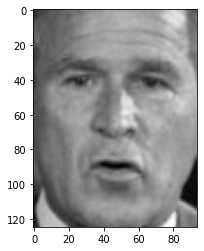

In [51]:
plt.imshow(img_orig.reshape(125,94), cmap="gray")

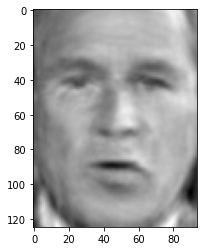

In [52]:
plt.imshow(img_trans.reshape(125,94), cmap="gray")

In [66]:
pca = model.named_steps['pca']
img_orig = X_test[30]
img_trans = pca.inverse_transform(pca.transform([img_orig]))[0]

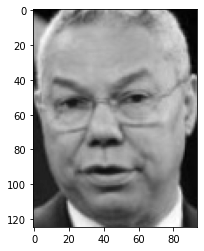

In [67]:
plt.imshow(img_orig.reshape(125,94), cmap="gray")

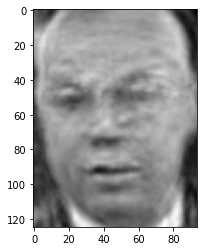

In [68]:
plt.imshow(img_trans.reshape(125,94), cmap="gray")

In [69]:
pca.components_.shape

(250, 11750)

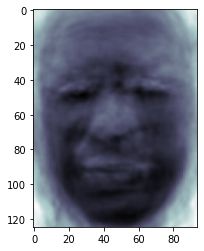

In [70]:
plt.imshow(pca.components_[0].reshape(125,94), cmap='bone')

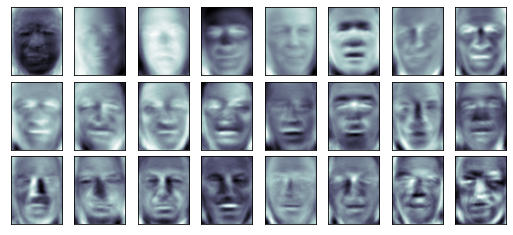

In [71]:
fig, axes = plt.subplots(3, 8, figsize=(9, 4),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(125, 94), cmap='bone')



In [72]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

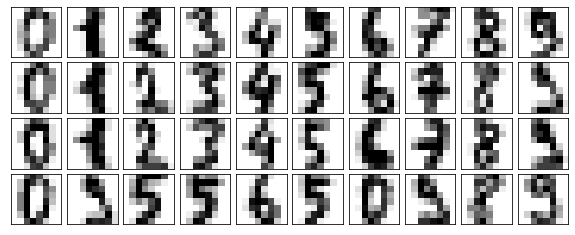

In [73]:
def plot_digits(data):
    fig, axes = plt.subplots(4, 10, figsize=(10, 4),
                             subplot_kw={'xticks':[], 'yticks':[]},
                             gridspec_kw=dict(hspace=0.1, wspace=0.1))
    for i, ax in enumerate(axes.flat):
        ax.imshow(data[i].reshape(8, 8),
                  cmap='binary', interpolation='nearest',
                  clim=(0, 16))
plot_digits(digits.data)



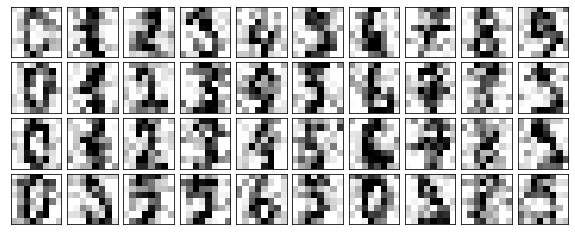

In [74]:
np.random.seed(42)
noisy = np.random.normal(digits.data, 4)
plot_digits(noisy)

In [75]:
pca = PCA(0.50).fit(noisy)
pca.n_components_

12

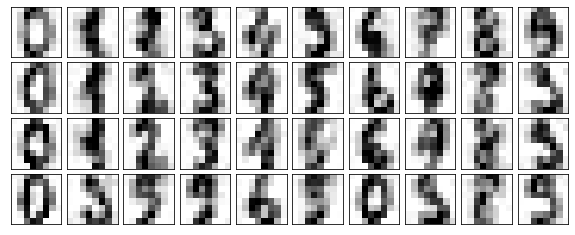

In [76]:
components = pca.transform(noisy)
filtered = pca.inverse_transform(components)
plot_digits(filtered)